In [1]:
%matplotlib inline

from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import numpy as np

dataset = read_csv("clean.csv")

## Troisième jalon : Apprentissage

Nous sommes prêts à passer à l’apprentissage à proprement parler. Pour ce faire, nous allons utiliser la bibliothèque scikit-learn.

### Préparation de données d’apprentissage et de test
Le but est d’estimer le prix d’un produit à partir des attributs. La colonne “Prix” correspond ainsi aux étiquettes ("targets"), tandis que les autres colonnes sont les attributs ("features").

**Question 15**: Préparez la matrice de données et le vecteur des étiquettes pour votre jeu de données. Séparez les données en un jeu d’entraînement et un jeu de test, sur un base 75%/25%, en utilisant
le paramètre random_state = 49.

Nous utiliserons les notations suivantes :

- X_train (resp. y_train) fait référence aux données d’apprentissage (resp. à leur étiquette),

- X_test (resp. y_test) fait référence aux données de test (resp. à leur étiquette).

In [2]:
X = dataset.drop("Prix", axis=1).values
y = dataset["Prix"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=49
)

### Premier modèle : Régression Linéaire

Dans un premier temps, nous allons appliquer une régression linéaire LinearRegression sur nos données.

**Question 16**: Évaluez ce modèle sur le jeu de test par r2_score. Rappelons qu’il s’agit de la mesure par défaut pour la fonction score() des méthodes de régression.

In [3]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print(f"LinearRegression score[r^2]: {lr.score(X_test, y_test):.6f}")

LinearRegression score[r^2]: 0.189665


**Question 17**: Nous allons Faire une comparaison entre les estimations (estim_LR) faites par le modèle pour les données de test et les prix y_test. Dessinez une figure où l’axe x représente estim_LR et l’axe y est y_test. Pensez à utiliser la fonction scatter pour représenter les points. Nous appellerons dans la suite figure de visualisation cette représentation. Rappelons que si votre modèle fonctionne bien pour ce jeu de données, vous devriez avoir les points autour de la diagonale
où estim_LR est égal à y_test. Que constatez-vous ?

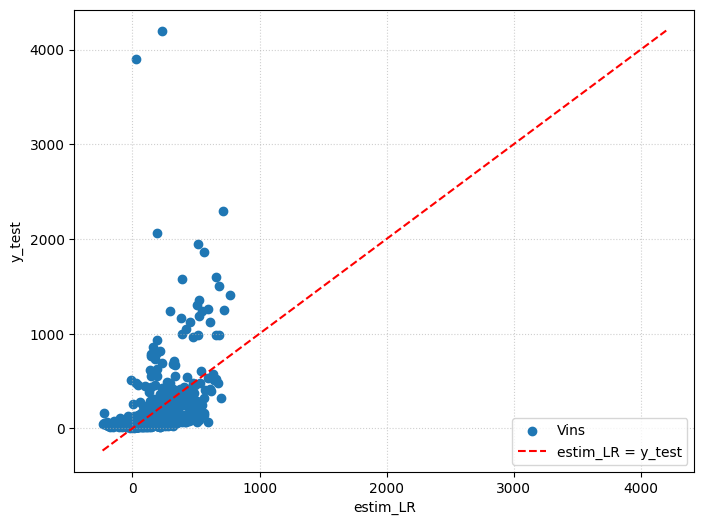

In [4]:
x_test_pred = lr.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(x_test_pred, y_test, label="Vins")


mn = min(x_test_pred.min(), y_test.min())
mx = max(x_test_pred.max(), y_test.max())

plt.plot(
    [mn, mx],
    [mn, mx],
    color="red",
    linestyle="--",
    label="estim_LR = y_test",
)

# b = lr.intercept_
# a = lr.coef_[0]

# # coef_tendance = np.polyfit(x_test_pred, y_test, 1)
# # p = np.poly1d(coef_tendance)
# # plt.plot([mn, mx], [p(mn), p(mx)], color="green", label="Tendance réelle du modèle")

plt.xlabel("estim_LR")
plt.ylabel("y_test")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

Je constate qu'il y a des bouteilles hors de prix et donc l'algorithme de regression linéaire ne prend pas suffisamment en compte ces valeurs là.

**Question 18**: Nous allons maintenant évaluer l’impact du pré-traitement sur nos données. En utilisant la commande make_pipeline, normalisez d’abord les données avant de lancer l’apprentissage, et évaluez le score sur le jeu de test. Répétez l’expérience, cette fois-ci en standardisant les données avant l’apprentissage. Dessinez les figures de visualisation pour les deux cas. Observez-vous les mêmes choses qu’à la question précédente ?

MinMaxScaler score[r^2]: 0.189665


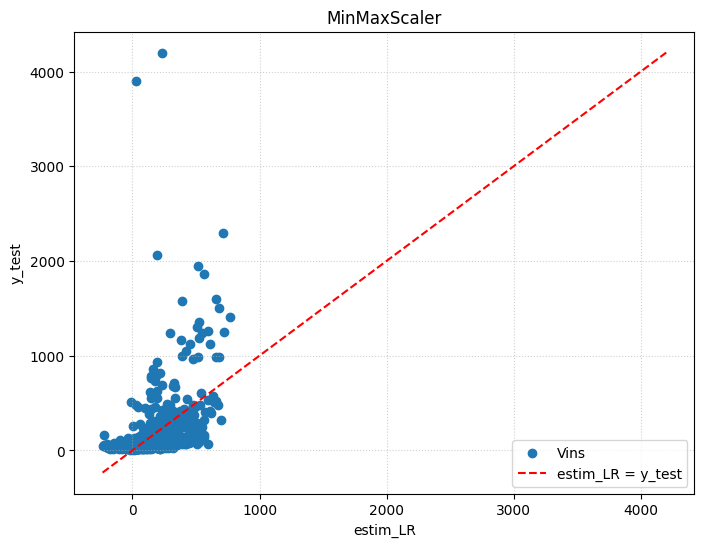

StandardScaler score[r^2]: 0.189665


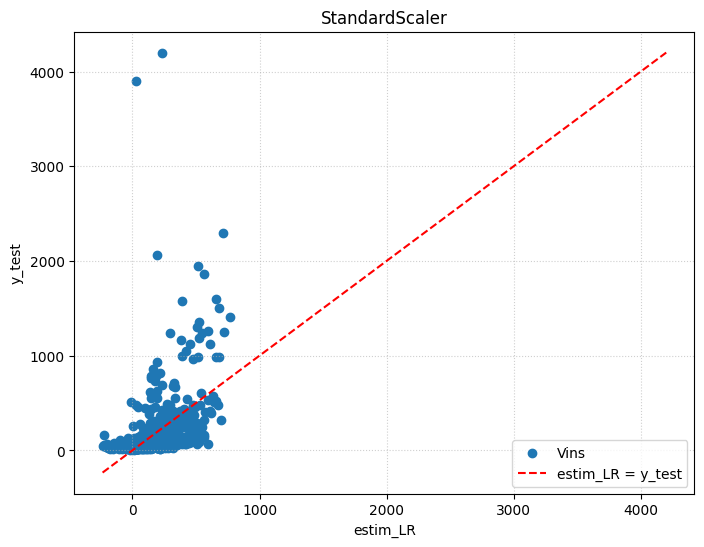

In [5]:
for scaler in [MinMaxScaler, StandardScaler]:
    pipeline = make_pipeline(scaler(), LinearRegression())
    pipeline.fit(X_train, y_train)

    x_test_pred = pipeline.predict(X_test)

    plt.figure(figsize=(8, 6))
    plt.scatter(x_test_pred, y_test, label="Vins")


    mn = min(x_test_pred.min(), y_test.min())
    mx = max(x_test_pred.max(), y_test.max())

    plt.plot(
        [mn, mx],[mn, mx], color="red",
        linestyle="--", label="estim_LR = y_test",
    )

    # b = lr.intercept_
    # a = lr.coef_[0]

    # x_reg = np.linspace(X_test[0].min(), X_test[0].max(), 100)
    # y_reg = a * x_reg + b
    # plt.plot(x_reg, y_reg, color='red', label=f"y = {a:.2f}x + {b:.2f}")

    plt.xlabel("estim_LR")
    plt.ylabel("y_test")
    plt.title(scaler.__name__)
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)

    print(f"{scaler.__name__} score[r^2]: {pipeline.score(X_test, y_test):.6f}")
    plt.show()

**Question 19**: Trouvez les valeurs minimales et maximales pour les prix dans votre dataset. Que peut-on dire de la dispersion des prix dans votre dataset ?
Dans le cas où les étiquettes sont trop dispersées, une solution pourrait être de modifier l’échelle des étiquettes. Pour ce faire, on pourrait transformer les prix de sorte que les prix utilisés dans
l’apprentissage soient ln(y[i]) à l’aide des fonctions ln et exp de la bibliothèque numphy. Quelles sont les nouvelles valeurs pour le prix minimum et maximum de votre dataset ?

In [6]:
print(f"Prix Min : {y.min():.2f}€")
print(f"Prix Max : {y.max():.2f}€")

y_log = np.log(y)

print(f"Log Min : {y_log.min():.4f}")
print(f"Log Max : {y_log.max():.4f}")

Prix Min : 6.20€
Prix Max : 17280.00€
Log Min : 1.8245
Log Max : 9.7573


|Méthode|r^2|
|----|----|
|LR|0.189665|
|Normalisation + LR|0.189665|
|Standardisation + LR|0.189665|